In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [26]:
raw_data=pd.read_excel(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\1I1V.xlsx')
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4537 entries, 0 to 4536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Created  4537 non-null   str  
 1   Message  4537 non-null   str  
 2   Status   4537 non-null   str  
dtypes: str(3)
memory usage: 106.5 KB


In [27]:
raw_data_codes=[]

for i in range(0,raw_data.shape[0]):
    raw_data_codes.append(raw_data.iloc[i,2][6:8])

raw_data['Codes']=raw_data_codes
raw_data['Codes'].value_counts()

Codes
02    3872
03     521
09      59
04      57
01      27
11       1
Name: count, dtype: int64

In [28]:
torch_codes_02=raw_data[raw_data['Codes'].str.contains('02')]
torch_codes_04=raw_data[raw_data['Codes'].str.contains('04')]
torch_codes_0204=pd.concat([torch_codes_02,torch_codes_04])

torch_codes_0204.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\torch_analysis.csv',sep=',')

ignition_on_interval=[]
ignition_off_interval=[]
io=[]
odometer=[]
date=[]
ext_ps=[]
speed=[]
#over_speed=[]
gnss=[]
#a_code=[]
#direction=[]
accum_fuel_consumption=[]
#instant_fuel_consumption=[]
rpm=[]
cool_temp=[]
#air_in_flow_temp=[]
engine_load=[]
remain_fuel_rate=[]

for i in range(0,torch_codes_0204.shape[0]):
    ignition_on_interval.append(int(torch_codes_0204.iloc[i,2][32:36],16))
    ignition_off_interval.append(int(torch_codes_0204.iloc[i,2][36:40],16))
    io.append(bin(int(torch_codes_0204.iloc[i,2][64:68],16)))
    odometer.append(int(torch_codes_0204.iloc[i,2][72:80],16))
    date.append(torch_codes_0204.iloc[i,2][82:94])
    ext_ps.append((float(int(torch_codes_0204.iloc[i,2][126:130])))/100)
    speed.append(int(torch_codes_0204.iloc[i,2][131:133]))    
    #over_speed.append(torch_codes_0204.iloc[i,2])
    gnss.append(int(torch_codes_0204.iloc[i,2][51:52],16))
    #a_code.append(torch_codes_0204.iloc[])
    #direction.append(torch_codes_0204.iloc[i,2])
    accum_fuel_consumption.append(float(int(torch_codes_0204.iloc[i,2][134:142],16))/1000)
    #instant_fuel_consumption.append(torch_codes_0204.iloc[i,2]) invalid!
    rpm.append(int(torch_codes_0204.iloc[i,2][150:154],16))
    cool_temp.append(int(torch_codes_0204.iloc[i,2][158:160],16))
    #air_in_flow_temp.append(torch_codes_0204.iloc[i,2])
    engine_load.append(int(torch_codes_0204.iloc[i,2][162:164],16))
    remain_fuel_rate.append(torch_codes_0204.iloc[i,2][166:168])

torch_codes_0204['i_on']=ignition_on_interval
torch_codes_0204['i_off']=ignition_off_interval
torch_codes_0204['io']=io
torch_codes_0204['odometer']=odometer
torch_codes_0204['date']=date
torch_codes_0204['ext_ps']=ext_ps
torch_codes_0204['speed']=speed
torch_codes_0204['gnss']=gnss
torch_codes_0204['acc_fuel_c']=accum_fuel_consumption
torch_codes_0204['rpm']=rpm
torch_codes_0204['cool_temp']=cool_temp
torch_codes_0204['remain_fuel']=remain_fuel_rate
torch_codes_0204['engine_load']=engine_load

torch_codes_0204_ordered=torch_codes_0204.sort_values('date',ascending=True)

print(torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','engine_load']])

      i_on  i_off                 io  odometer          date  ext_ps  speed  \
0       25    600  0b100000000000000    134621  260913000015   28.34      0   
1       25    600  0b100000000000000    134652  260913000040   28.46     12   
2       25    600  0b100000000000000    134734  260913000105   28.42     14   
3       25    600  0b100000000000000    134909  260913000130   28.46     27   
4       25    600  0b100000000000000    135067  260913000150   28.27     23   
...    ...    ...                ...       ...           ...     ...    ...   
4523    25    600  0b100000000000000    753598  260914203520   26.72      0   
4525    25    600                0b0    753598  260914203527   26.69      0   
4528    25    600                0b0    753598  260914204547   25.73      0   
4531    25    600                0b0    753598  260914205546   25.76      0   
4534    25    600                0b0    753598  260914210547   25.74      0   

      acc_fuel_c   rpm remain_fuel  gnss  cool_temp

In [29]:
torch_codes_0204_ordered.info()

<class 'pandas.DataFrame'>
Index: 3929 entries, 0 to 4534
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Created      3929 non-null   str    
 1   Message      3929 non-null   str    
 2   Status       3929 non-null   str    
 3   Codes        3929 non-null   str    
 4   i_on         3929 non-null   int64  
 5   i_off        3929 non-null   int64  
 6   io           3929 non-null   str    
 7   odometer     3929 non-null   int64  
 8   date         3929 non-null   str    
 9   ext_ps       3929 non-null   float64
 10  speed        3929 non-null   int64  
 11  gnss         3929 non-null   int64  
 12  acc_fuel_c   3929 non-null   float64
 13  rpm          3929 non-null   int64  
 14  cool_temp    3929 non-null   int64  
 15  remain_fuel  3929 non-null   str    
 16  engine_load  3929 non-null   int64  
dtypes: float64(2), int64(8), str(7)
memory usage: 552.5 KB


In [30]:
df=torch_codes_0204_ordered[['i_on','i_off','io','odometer','date','ext_ps','speed','acc_fuel_c','rpm','remain_fuel','gnss','cool_temp','Status','engine_load']]
df.info()

<class 'pandas.DataFrame'>
Index: 3929 entries, 0 to 4534
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   i_on         3929 non-null   int64  
 1   i_off        3929 non-null   int64  
 2   io           3929 non-null   str    
 3   odometer     3929 non-null   int64  
 4   date         3929 non-null   str    
 5   ext_ps       3929 non-null   float64
 6   speed        3929 non-null   int64  
 7   acc_fuel_c   3929 non-null   float64
 8   rpm          3929 non-null   int64  
 9   remain_fuel  3929 non-null   str    
 10  gnss         3929 non-null   int64  
 11  cool_temp    3929 non-null   int64  
 12  Status       3929 non-null   str    
 13  engine_load  3929 non-null   int64  
dtypes: float64(2), int64(8), str(4)
memory usage: 460.4 KB


Odometer

134621
134621
134652
134652
134734
134734
134909
134909
135067
135067
135102
135102
135148
135148
135148
135148
135148
135148
135148
135148
135148
135148
135148
135148
135148
135148
135259
135259
135641
135641
135733
135733
135830
135830
135847
135847
135868
135868
135905
135905
136285
136285
136784
136784
137339
137339
137906
137906
138398
138398
138893
138893
139366
139366
139543
139543
140059
140059
140320
140320
140820
140820
141286
141286
141610
141610
141638
141638
141639
141639
141639
141639
141639
141639
141639
141639
141639
141639
141639
141639
141639
141639
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141643
141761
141761
142154
142154
142579
142579
142996
142996
143330
143330
143444
143444
143885
143885
143980
143980
144008
144008
144008
144008
144008
144008
144008

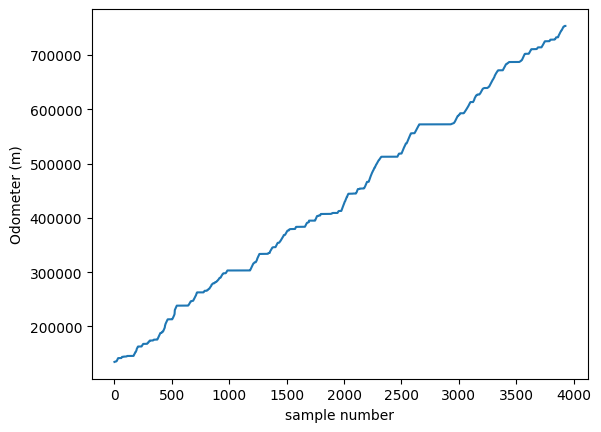

In [31]:
odometer=pd.DataFrame()
odometer_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    print(int(df.iloc[i,3]))
    #if int(df.iloc[i,3]>80000000):
    print(int(df.iloc[i,3]))
    status.append(df.iloc[i,12])
    odometer_data.append(int(df.iloc[i,3]))
    date.append(df.iloc[i,4])
    x_axis.append(i)
try:
    print(max(odometer_data),min(odometer_data))
except:
    print(df.iloc[i,3])

odometer['sample_number']=x_axis
odometer['odometer']=odometer_data
odometer['date']=date
odometer['status']=status

plt.ylabel("Odometer (m)")
plt.xlabel('sample number')
#plt.xticks(range(0,5572,100),rotation=90)
plt.plot(x_axis,odometer_data)

odometer.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\odometer.csv')

The lower peak was caused by MinsDiff=504.
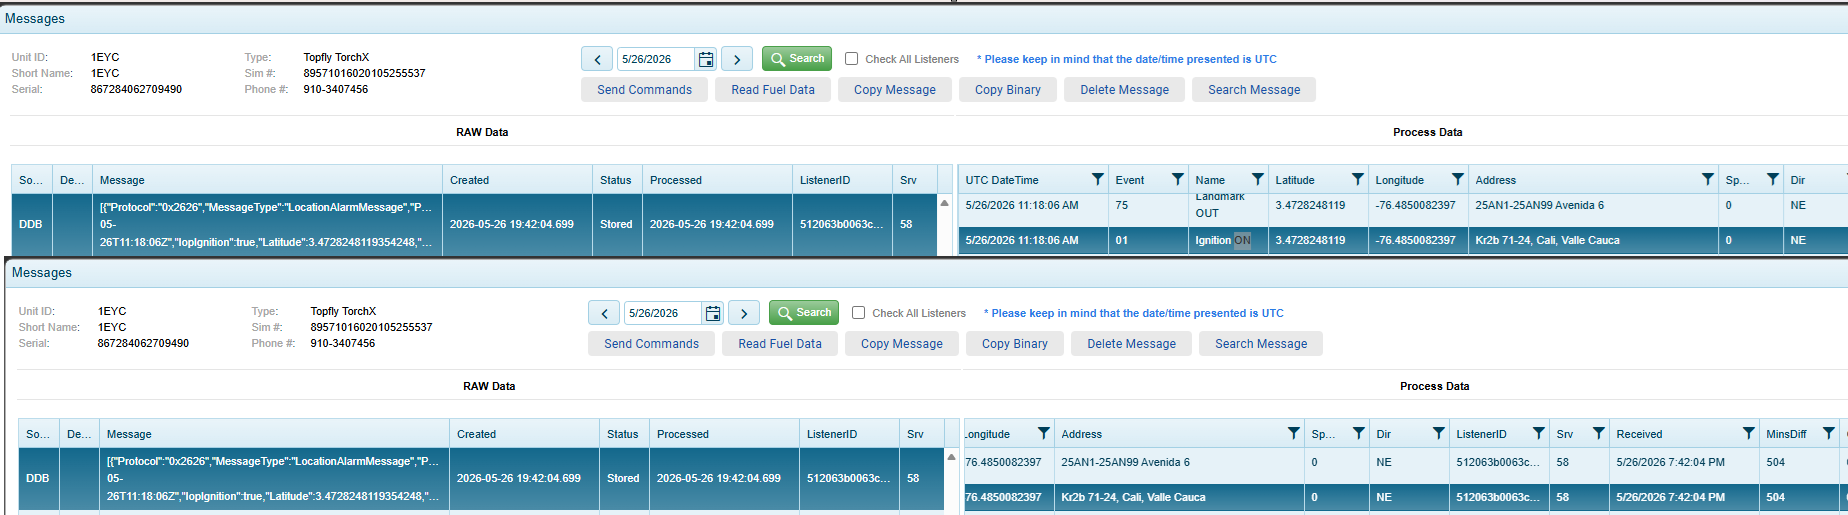

Speed

86 0


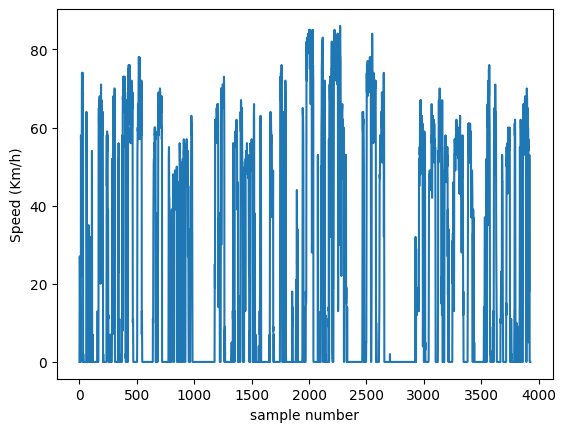

In [32]:
speed=pd.DataFrame()
speed_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):                        
        status.append(df.iloc[i,12])
        speed_data.append(int(df.iloc[i,6]))
        date.append(df.iloc[i,4])
        x_axis.append(i)            

print(max(speed_data),min(speed_data))
speed['sample_number']=x_axis
speed['speed']=speed_data
speed['status']=status

plt.ylabel("Speed (Km/h)")
plt.xlabel('sample number')
plt.plot(x_axis,speed_data)

speed.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\speed.csv')

RPM

2420 0


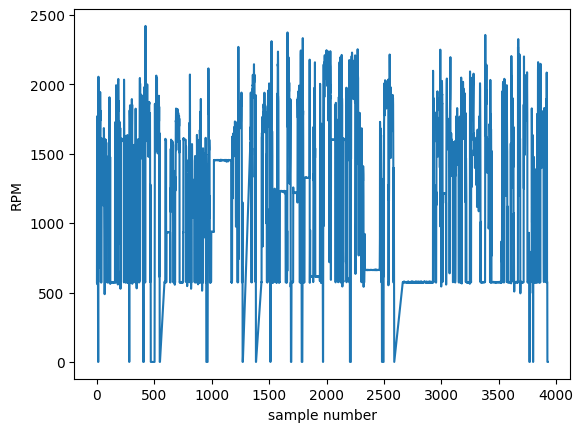

In [33]:
rpm=pd.DataFrame()
rpm_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
        if df.iloc[i,8]<65535:
                status.append(df.iloc[i,12])
                rpm_data.append(int(df.iloc[i,8]))
                date.append(df.iloc[i,4])
                x_axis.append(i)            

print(max(rpm_data),min(rpm_data))
rpm['sample_number']=x_axis
rpm['rpm']=rpm_data
rpm['status']=status

plt.ylabel("RPM")
plt.xlabel('sample number')
plt.plot(x_axis,rpm_data)
#rpm.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rpm.csv')

Fuel

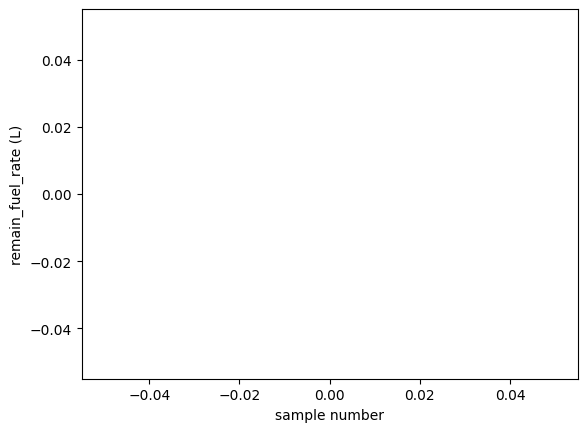

In [34]:
rfl=pd.DataFrame()
fuel_data=[]
x_axis=[]
date=[]
status=[]
status_aux=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,9]!='FF':               
        aux_data=df.iloc[i,12]
        if (len(aux_data)<170):
            status.append(df.iloc[i,12])
            x_axis.append(i) 
            fuel_data.append((int(df.iloc[i,9],16) & 127))
            date.append(df.iloc[i,4])

plt.plot(x_axis,fuel_data)
plt.ylabel("remain_fuel_rate (L)")
plt.xlabel('sample number')

rfl['fuel_data']=fuel_data
rfl['date']=date
rfl['raw_data']=status
rfl.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\rfl_1i1v.csv',sep=',')

Cooling fluid Temperature 

98 0


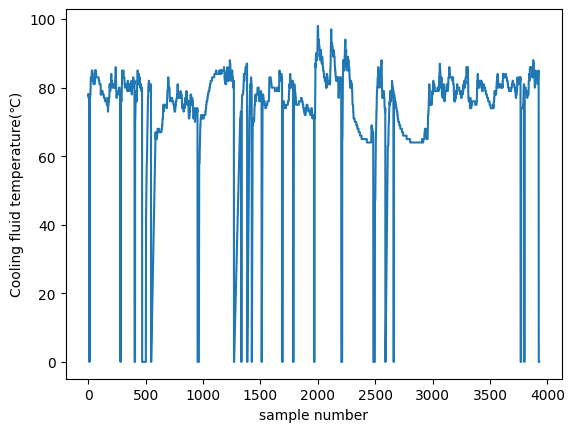

In [35]:
temp=pd.DataFrame()
temp_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,11]!=255:               
        aux_data=df.iloc[i,11]
        status.append(df.iloc[i,12])
        temp_data.append(df.iloc[i,11]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
temp['sample_number']=x_axis
temp['date']=date
temp['temp']=temp_data
temp['status']=status

plt.ylabel("Cooling fluid temperature(℃)")
plt.xlabel('sample number')
plt.plot(x_axis,temp_data)

temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\temp.csv')

Engine load

98 0


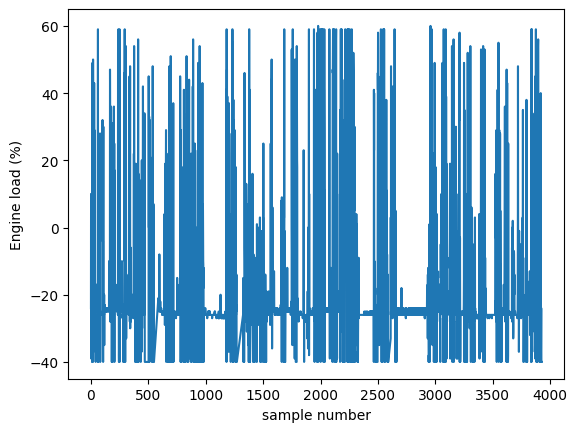

In [36]:
engine_load=pd.DataFrame()
engine_data=[]
x_axis=[]
date=[]
status=[]
#torch_codes_0204.info()

for i in range(0,df.shape[0]):
    if df.iloc[i,13]!=255:               
        aux_data=df.iloc[i,13]
        status.append(df.iloc[i,12])
        engine_data.append(df.iloc[i,13]-40)
        x_axis.append(i)         
        date.append(df.iloc[i,4])

print(max(temp_data),min(temp_data))
engine_load['sample_number']=x_axis
engine_load['date']=date
engine_load['engine load %']=engine_data
engine_load['status']=status

plt.ylabel("Engine load (%)")
plt.xlabel('sample number')
plt.plot(x_axis,engine_data)

temp.to_csv(r'C:\Users\Jose.Hurtado\Documents\Zonar_projects\data\zonar\engine.csv')
